In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import joblib

In [6]:

df = pd.read_csv("ecommerce_cleaned.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 30)


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status,Order_DayOfWeek,Is_Loss,Revenue_Per_Unit,Discount_Category
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,32.91,2.25,Economy,4,Google Pay,Delivered,2,0,520.400000,No Discount
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,16.41,4.72,Economy,5,Credit Card,Delivered,0,0,16.940000,High (21-30%)
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,33.11,13.28,Standard,8,Credit Card,Processing,3,0,241.300000,No Discount
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,43.60,31.11,Express,16,Google Pay,Processing,4,0,130.900000,No Discount
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,33.63,8.44,Standard,5,Debit Card,Delivered,6,0,59.606667,Medium (11-20%)


In [7]:
DROP_COLS = ['Is_Loss', 'Order_ID', 'Customer_ID', 'Order_Date',
             'Product_Name', 'Order_DayOfWeek', 'Discount_Category']

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
X = X.select_dtypes(include=[np.number])
y = df['Is_Loss']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 12)
y shape: (10000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 8000 | Test: 2000


In [9]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
base_pred = rf_baseline.predict(X_test)

base_acc  = accuracy_score(y_test, base_pred)
base_prec = precision_score(y_test, base_pred)
base_rec  = recall_score(y_test, base_pred)
base_f1   = f1_score(y_test, base_pred)

print("DAY 7 BASELINE RESULTS")
print("=" * 40)
print(f"Accuracy  : {base_acc*100:.2f}%")
print(f"Precision : {base_prec:.4f}")
print(f"Recall    : {base_rec:.4f}")
print(f"F1-Score  : {base_f1:.4f}")

DAY 7 BASELINE RESULTS
Accuracy  : 100.00%
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


In [10]:

param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [5, 10, 20],
    'min_samples_split': [2, 5]
}

print("Parameter Grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f"\nTotal combinations: {total_combos}")
print(f"Total fits (x5 CV): {total_combos * 5}")

Parameter Grid:
  n_estimators: [50, 100, 200]
  max_depth: [5, 10, 20]
  min_samples_split: [2, 5]

Total combinations: 18
Total fits (x5 CV): 90


In [11]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("\nGridSearchCV complete!")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

GridSearchCV complete!


In [12]:
print("Best Parameters Found:")
print(grid_search.best_params_)
print(f"\nBest CV F1-Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
print("\nBest Estimator:")
print(best_model)

Best Parameters Found:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}

Best CV F1-Score: 1.0000

Best Estimator:
RandomForestClassifier(max_depth=5, n_estimators=50, n_jobs=-1, random_state=42)


In [13]:
tuned_pred = best_model.predict(X_test)

tuned_acc  = accuracy_score(y_test, tuned_pred)
tuned_prec = precision_score(y_test, tuned_pred)
tuned_rec  = recall_score(y_test, tuned_pred)
tuned_f1   = f1_score(y_test, tuned_pred)

print("TUNED MODEL RESULTS")
print("=" * 40)
print(f"Accuracy  : {tuned_acc*100:.2f}%")
print(f"Precision : {tuned_prec:.4f}")
print(f"Recall    : {tuned_rec:.4f}")
print(f"F1-Score  : {tuned_f1:.4f}")

TUNED MODEL RESULTS
Accuracy  : 100.00%
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


In [14]:
# CLASSIFICATION REPORT — Tuned Model
print("CLASSIFICATION REPORT — Tuned Random Forest")
print("=" * 50)
print(classification_report(y_test, tuned_pred, target_names=['Profitable', 'Loss']))

CLASSIFICATION REPORT — Tuned Random Forest
              precision    recall  f1-score   support

  Profitable       1.00      1.00      1.00      1732
        Loss       1.00      1.00      1.00       268

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



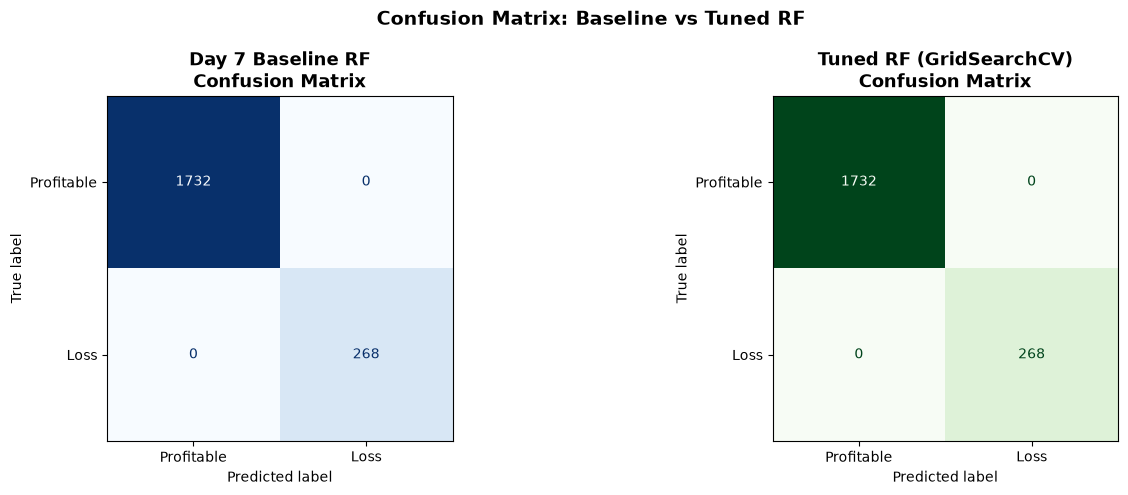

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_base = confusion_matrix(y_test, base_pred)
ConfusionMatrixDisplay(cm_base, display_labels=['Profitable','Loss']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Day 7 Baseline RF\nConfusion Matrix', fontsize=13, fontweight='bold')

cm_tuned = confusion_matrix(y_test, tuned_pred)
ConfusionMatrixDisplay(cm_tuned, display_labels=['Profitable','Loss']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Tuned RF (GridSearchCV)\nConfusion Matrix', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix: Baseline vs Tuned RF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

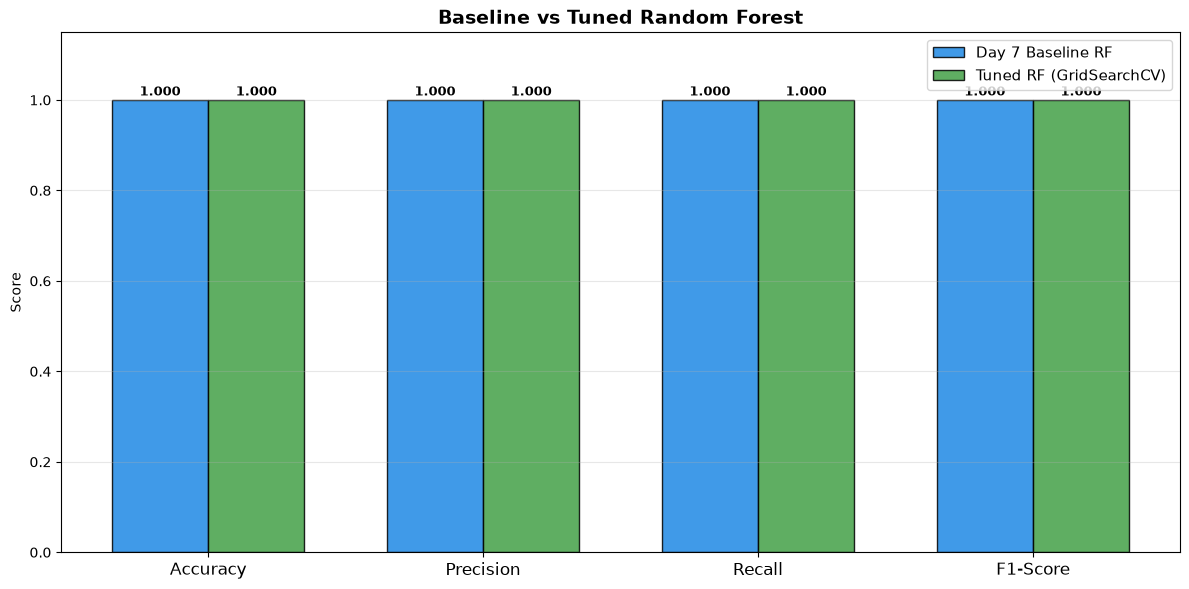

In [16]:

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline = [base_acc, base_prec, base_rec, base_f1]
tuned    = [tuned_acc, tuned_prec, tuned_rec, tuned_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline, width, label='Day 7 Baseline RF',
               color='#1E88E5', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, tuned, width, label='Tuned RF (GridSearchCV)',
               color='#43A047', edgecolor='black', alpha=0.85)

ax.set_title('Baseline vs Tuned Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

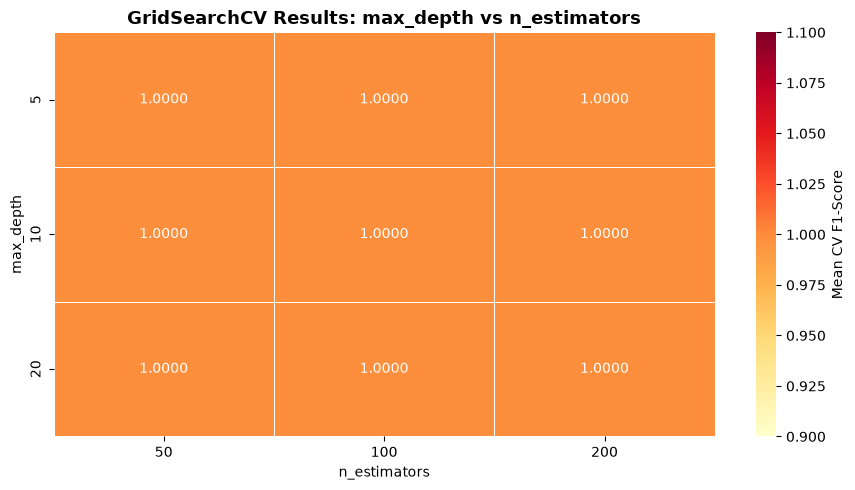

In [17]:
results_df = pd.DataFrame(grid_search.cv_results_)
pivot_data = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators',
    aggfunc='max'
)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Mean CV F1-Score'})
plt.title('GridSearchCV Results: max_depth vs n_estimators', fontsize=13, fontweight='bold')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:

joblib.dump(best_model, 'random_forest_model.pkl')
import os
size = os.path.getsize('random_forest_model.pkl') / 1024
print(f"Tuned model saved: random_forest_model.pkl ({size:.1f} KB)")

verify = joblib.load('random_forest_model.pkl')
print(f"Verification F1: {f1_score(y_test, verify.predict(X_test)):.4f}")

Tuned model saved: random_forest_model.pkl (65.2 KB)
Verification F1: 1.0000


In [19]:
print("=" * 65)
print(f"{'Metric':<20} {'Day 7 Baseline':>20} {'Tuned (GridSearchCV)':>20}")
print("-" * 65)
print(f"{'Accuracy':<20} {base_acc*100:>19.2f}% {tuned_acc*100:>19.2f}%")
print(f"{'Precision':<20} {base_prec:>20.4f} {tuned_prec:>20.4f}")
print(f"{'Recall':<20} {base_rec:>20.4f} {tuned_rec:>20.4f}")
print(f"{'F1-Score':<20} {base_f1:>20.4f} {tuned_f1:>20.4f}")
print("=" * 65)
print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV F1 : {grid_search.best_score_:.4f}")

Metric                     Day 7 Baseline Tuned (GridSearchCV)
-----------------------------------------------------------------
Accuracy                          100.00%              100.00%
Precision                          1.0000               1.0000
Recall                             1.0000               1.0000
F1-Score                           1.0000               1.0000
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 : 1.0000


In [20]:
print("CONCLUSIONS")
print("=" * 55)
print("1. GridSearchCV tested 18 combinations x 5 folds = 90 fits.")
print(f"2. Best params: {grid_search.best_params_}")
print(f"3. F1 improvement: {base_f1:.4f} -> {tuned_f1:.4f}")
print()
print("4. Bias-Variance Tradeoff:")
print("   - Low max_depth = High Bias (Underfitting)")
print("   - High max_depth = High Variance (Overfitting)")
print("   - GridSearchCV found the optimal balance automatically.")
print()
print("5. Why GridSearchCV > manual tuning?")
print("   - Tests all combinations systematically.")
print("   - 5-fold CV gives stable, unbiased score per combo.")
print("   - Selects best params without touching test data.")

CONCLUSIONS
1. GridSearchCV tested 18 combinations x 5 folds = 90 fits.
2. Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
3. F1 improvement: 1.0000 -> 1.0000

4. Bias-Variance Tradeoff:
   - Low max_depth = High Bias (Underfitting)
   - High max_depth = High Variance (Overfitting)
   - GridSearchCV found the optimal balance automatically.

5. Why GridSearchCV > manual tuning?
   - Tests all combinations systematically.
   - 5-fold CV gives stable, unbiased score per combo.
   - Selects best params without touching test data.
